In [1]:
import time
import sys

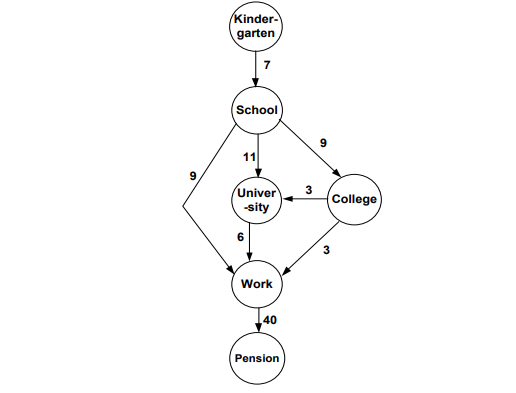

In [2]:
vertices = ["Kindergarten", "School", "University", "Work", "College", "Pension"]

### Этап 2. Формирование матрицы смежности

In [3]:
matrix_smeg = [
    [0, 7, 0, 0, 0, 0],
    [0, 0, 11, 9, 9, 0],
    [0, 0, 0, 6, 0, 0],
    [0, 0, 0, 0, 0, 40],
    [0, 0, 3, 3, 0, 0],
    [0, 0, 0, 0, 0, 0]
]
n = len(vertices)

### Этап 3. Построение списка ребер

In [4]:
def build_edge_list(matrix):
    edges = []
    n = len(matrix)

    for i in range(n):
        for j in range(n):
            if matrix[i][j] != 0:
                edges.append((i, j, matrix[i][j]))

    return edges

In [5]:
edges = build_edge_list(matrix_smeg)
edges

[(0, 1, 7),
 (1, 2, 11),
 (1, 3, 9),
 (1, 4, 9),
 (2, 3, 6),
 (3, 5, 40),
 (4, 2, 3),
 (4, 3, 3)]

### Этап 4. Представление графа в виде массива записей

In [6]:
def build_records(matrix, vertices):
    records = []
    n = len(matrix)

    for i in range(n):
        parents = []
        childs = []
        in_w = []
        out_w = []

        for j in range(n):
            if matrix[j][i] != 0:
                parents.append(vertices[j])
                in_w.append(matrix[j][i])

            if matrix[i][j] != 0:
                childs.append(vertices[j])
                out_w.append(matrix[i][j])

        record = {
            "index": i,
            "name": vertices[i],
            "parents": parents,
            "childs": childs,
            "in_weights": in_w,
            "out_weights": out_w
        }

        records.append(record)

    return records

In [7]:
records = build_records(matrix_smeg, vertices)

for r in records:
    # display(r)
    print(r)

{'index': 0, 'name': 'Kindergarten', 'parents': [], 'childs': ['School'], 'in_weights': [], 'out_weights': [7]}
{'index': 1, 'name': 'School', 'parents': ['Kindergarten'], 'childs': ['University', 'Work', 'College'], 'in_weights': [7], 'out_weights': [11, 9, 9]}
{'index': 2, 'name': 'University', 'parents': ['School', 'College'], 'childs': ['Work'], 'in_weights': [11, 3], 'out_weights': [6]}
{'index': 3, 'name': 'Work', 'parents': ['School', 'University', 'College'], 'childs': ['Pension'], 'in_weights': [9, 6, 3], 'out_weights': [40]}
{'index': 4, 'name': 'College', 'parents': ['School'], 'childs': ['University', 'Work'], 'in_weights': [9], 'out_weights': [3, 3]}
{'index': 5, 'name': 'Pension', 'parents': ['Work'], 'childs': [], 'in_weights': [40], 'out_weights': []}


### Этап 5. Визуализация графа

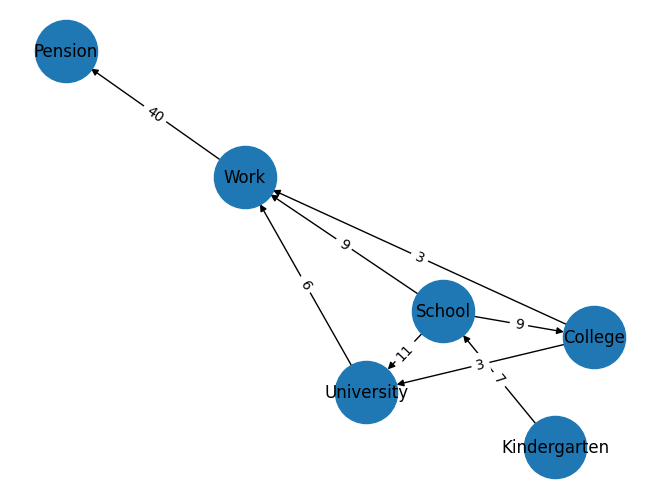

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for v in vertices:
    G.add_node(v)

for a, b, w in edges:
    G.add_edge(vertices[a], vertices[b], weight=w)

pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(vertices[a], vertices[b]): w for a, b, w in edges}
)

plt.show()

### Этап 6. Реализация подпрограмм для работы с графом

#### Матрица

In [9]:
# 1. Соседи
def neighbors_matrix(v):
    res = []
    for i in range(n):
        if matrix_smeg[v][i] != 0 or matrix_smeg[i][v] != 0:
            res.append(vertices[i])
    return res

# 2. Проверка цепи
def is_chain_matrix(path):
    for i in range(len(path)-1):
        if matrix_smeg[path[i]][path[i+1]] == 0:
            return False
    return True

# 3. Сумма весов > k
def sum_weights_matrix(k):
    res = []
    for i in range(n):
        s = sum(matrix_smeg[i]) + sum(matrix_smeg[j][i] for j in range(n))
        if s > k:
            res.append(i)
    return res

# 4. Кол-во ребер
def count_edges_matrix():
    return len(edges)

#### Список ребер

In [10]:
def neighbors_edges(v):
    res = set()
    for a,b,w in edges:
        if a == v:
            res.add(vertices[b])
        if b == v:
            res.add(vertices[a])
    return list(res)

def is_chain_edges(path):
    for i in range(len(path)-1):
        found = False
        for a,b,w in edges:
            if a == path[i] and b == path[i+1]:
                found = True
        if not found:
            return False
    return True

def sum_weights_edges(k):
    res = []
    for i in range(n):
        s = sum(w for a,b,w in edges if a==i or b==i)
        if s > k:
            res.append(i)
    return res

def count_edges_edges():
    return len(edges)

#### Записи

In [11]:
def neighbors_records(v):
    return records[v]["parents"] + records[v]["childs"]

def is_chain_records(path):
    for i in range(len(path)-1):
        if vertices[path[i+1]] not in records[path[i]]["childs"]:
            return False
    return True

def sum_weights_records(k):
    res = []
    for r in records:
        s = sum(r["in_weights"]) + sum(r["out_weights"])
        if s > k:
            res.append(r["index"])
    return res

def count_edges_records():
    return sum(len(r["childs"]) for r in records)

### Этап 7. Размеры

In [12]:
print("Размер матрицы:", sys.getsizeof(matrix_smeg))
print("Размер списка ребер:", sys.getsizeof(edges))
print("Размер записей:", sys.getsizeof(records))

Размер матрицы: 104
Размер списка ребер: 120
Размер записей: 120


### Этап 8. Время выполнения

In [20]:
# 8. Время выполнения
import time

REPEATS = 100_000

def measure(func, *args):
    start = time.perf_counter()
    for _ in range(REPEATS):
        func(*args)
    end = time.perf_counter()
    return (end - start) / REPEATS  # среднее время


In [32]:
tests = [
    ("neighbors_matrix", neighbors_matrix, (1,)),
    ("is_chain_matrix", is_chain_matrix, ([0,1,2],)),
    ("sum_weights_matrix", sum_weights_matrix, (10,)),
    ("count_edges_matrix", count_edges_matrix, ()),

    ("neighbors_edges", neighbors_edges, (1,)),
    ("is_chain_edges", is_chain_edges, ([0,1,2],)),
    ("sum_weights_edges", sum_weights_edges, (10,)),
    ("count_edges_edges", count_edges_edges, ()),

    ("neighbors_records", neighbors_records, (1,)),
    ("is_chain_records", is_chain_records, ([0,1,2],)),
    ("sum_weights_records", sum_weights_records, (10,)),
    ("count_edges_records", count_edges_records, ())
]

# Вывод таблицы
print(f"{'Функция':<25} | {'Среднее время'}")
print("-" * 50)

for name, func, args in tests:
    t = measure(func, *args)
    print(f"{name:<25} | {t:.10f}")

Функция                   | Среднее время
--------------------------------------------------
neighbors_matrix          | 0.0000005465
is_chain_matrix           | 0.0000002512
sum_weights_matrix        | 0.0000044400
count_edges_matrix        | 0.0000000585
neighbors_edges           | 0.0000005570
is_chain_edges            | 0.0000007909
sum_weights_edges         | 0.0000036778
count_edges_edges         | 0.0000000591
neighbors_records         | 0.0000001238
is_chain_records          | 0.0000002813
sum_weights_records       | 0.0000009479
count_edges_records       | 0.0000005463
